### imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from my_ml.datasets import load_spambase

In [2]:
from my_ml.linear_models.regression import LinearRegression
from my_ml.preprocessing import Data_split,KFold
from my_ml.mytorch import tensor

In [3]:
import unittest
import torch

In [4]:
from my_ml.trees import DecisionTree_Classification, DecisionTree_Regression,RandomForestClassification

In [5]:
import numpy as np

def confusion_matrix(y_true, y_pred):
    classes = np.unique(np.concatenate((y_true, y_pred)))
    n = len(classes)
    cm = np.zeros((n, n), dtype=int)

    class_to_idx = {cls: i for i, cls in enumerate(classes)}

    for t, p in zip(y_true, y_pred):
        cm[class_to_idx[t], class_to_idx[p]] += 1

    return cm


In [6]:
def make_noisy_sine(n_samples=100, noise_std=0.1, random_state=None):
    rng = np.random.RandomState(random_state)
    X = np.linspace(-2*np.pi, 2*np.pi, n_samples)
    y = np.sin(X) + rng.normal(scale=noise_std, size=n_samples)
    return X, y

### Decision Trees

In [7]:
X,y = load_spambase()

In [8]:
(X_train,y_train),(X_test,y_test),(X_val,y_val) = Data_split(X,y,[0.5,0.25],True,True)

In [9]:
fold = KFold(k_split=5,shuffle=True)
splits = list(fold.split(X))

In [10]:
X, y = fetch_california_housing(return_X_y=True)

In [11]:
model = DecisionTree_Regression(
   threshold=0.01,
   max_depth=5,
   min_samples_split=80,
   min_samples_leaf=40,
)


In [12]:
model.fit(X,y)

In [13]:
y_pred = model.predict(X)

### PCA test

In [14]:
from my_ml.decomposition import PCA,KPCA

In [15]:
X,y = load_spambase()

In [16]:
decomp = KPCA(n_components=2,gamma=1.0)
decomp.fit(X)

In [17]:
X_trans = decomp.transform(X)

In [18]:
X_trans

array([[4.97802848e-06, 4.97938295e-06],
       [3.24702633e-06, 3.22263730e-06],
       [3.24626258e-06, 3.22186819e-06],
       ...,
       [3.24894779e-06, 3.22457240e-06],
       [3.50018160e-06, 3.47790223e-06],
       [3.24672763e-06, 3.22233660e-06]], shape=(4601, 2))

### testing tensor

In [13]:
class TestAutoGradFinal(unittest.TestCase):
    
    def setUp(self):
        self.rtol = 1e-4
        self.atol = 1e-6

    def create_tensor(self, data, requires_grad=False):
        return tensor(data, required_grad=requires_grad)

    def check(self, my_tensor, torch_tensor, name="Tensor"):
        # 1. Check Data
        my_data = np.array(my_tensor.data).squeeze()
        py_data = torch_tensor.detach().numpy().squeeze()
        np.testing.assert_allclose(
            my_data, py_data, rtol=self.rtol, atol=self.atol,
            err_msg=f"{name} Forward Data mismatch"
        )
        
        # 2. Check Gradients (if they exist)
        if torch_tensor.grad is not None:
            # Handle the case where your grad is None (treat as 0) or scalar vs vector
            my_grad = my_tensor.grad if my_tensor.grad is not None else np.zeros_like(my_data)
            my_grad = np.array(my_grad).squeeze()
            
            py_grad = torch_tensor.grad.numpy().squeeze()
            
            np.testing.assert_allclose(
                my_grad, py_grad, rtol=self.rtol, atol=self.atol,
                err_msg=f"{name} Gradient mismatch"
            )

    def test_full_integration(self):
        """
        The 'Torture Test': A mini neural network update step.
        Input (Batch=2, Dim=3) -> Linear(3->2) -> ReLU -> MeanSquaredError
        """
        print("\nRunning Full Integration Test...")
        
        # Setup Data
        x_np = np.random.randn(2, 3)
        w_np = np.random.randn(3, 2)
        b_np = np.random.randn(2)
        
        # --- My Autograd ---
        tX = self.create_tensor(x_np, requires_grad=True)
        tW = self.create_tensor(w_np, requires_grad=True)
        tb = self.create_tensor(b_np, requires_grad=True)
        
        # Forward
        z = tX @ tW + tb      # Linear
        a = z.relu()          # Activation
        loss = (a ** 2).mean() # MSE-like Loss
        
        # Backward
        loss.backward()

        # --- PyTorch Oracle ---
        pX = torch.tensor(x_np, requires_grad=True)
        pW = torch.tensor(w_np, requires_grad=True)
        pb = torch.tensor(b_np, requires_grad=True)
        
        # Forward
        pz = pX @ pW + pb
        pa = torch.relu(pz)
        ploss = (pa ** 2).mean()
        
        # Backward
        ploss.retain_grad()
        ploss.backward()

        # --- Verification ---
        print("Checking Forward...")
        self.check(loss, ploss, "Loss")
        
        print("Checking Gradients...")
        self.check(tW, pW, "Weights (W)")
        self.check(tb, pb, "Bias (b) [Broadcasting Check]")
        self.check(tX, pX, "Input (X)")
        
        print(">> FULL INTEGRATION PASSED!")

if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

.
----------------------------------------------------------------------
Ran 1 test in 0.022s

OK



Running Full Integration Test...
Checking Forward...
Checking Gradients...
>> FULL INTEGRATION PASSED!


In [14]:
class TestOps(unittest.TestCase):
    
    def setUp(self):
        self.rtol = 1e-4
        self.atol = 1e-6

    def create_tensor(self, data, requires_grad=False):
        """Helper to create your tensor with correct argument name."""
        return tensor(data, required_grad=requires_grad)

    def check(self, my_tensor, torch_tensor, op_name):
        """Generic checker for data and gradients."""
        # 1. Check Forward Data
        my_data = np.array(my_tensor.data).squeeze()
        py_data = torch_tensor.detach().numpy().squeeze()
        
        np.testing.assert_allclose(
            my_data, py_data, rtol=self.rtol, atol=self.atol,
            err_msg=f"[{op_name}] Forward pass data mismatch"
        )
        
        # 2. Check Backward Gradients
        if torch_tensor.grad is not None:
            if my_tensor.grad is None:
                my_grad = np.zeros_like(my_data)
            else:
                my_grad = np.array(my_tensor.grad).squeeze()
                
            py_grad = torch_tensor.grad.numpy().squeeze()
            
            np.testing.assert_allclose(
                my_grad, py_grad, rtol=self.rtol, atol=self.atol,
                err_msg=f"[{op_name}] Gradient mismatch"
            )

    # ==========================================
    # 1. ARITHMETIC OPS (Add, Mul)
    # ==========================================

    def test_add_op(self):
        print("Testing AddOp (Broadcasting)...")
        # Shapes: (2,3) + (1,3) -> Broadcasting check
        x_np = np.random.randn(2, 3)
        y_np = np.random.randn(1, 3)

        # Mine
        t1 = self.create_tensor(x_np, requires_grad=True)
        t2 = self.create_tensor(y_np, requires_grad=True)
        out = t1 + t2
        out.backward()

        # PyTorch
        p1 = torch.tensor(x_np, requires_grad=True)
        p2 = torch.tensor(y_np, requires_grad=True)
        p_out = p1 + p2
        p_out.retain_grad()
        p_out.backward(torch.ones_like(p_out))

        self.check(t1, p1, "AddOp (Input 1)")
        self.check(t2, p2, "AddOp (Input 2 - Broadcasted)")

    def test_mul_op(self):
        print("Testing MulOp (Element-wise)...")
        x_np = np.random.randn(3, 3)
        y_np = np.random.randn(3, 3)

        t1 = self.create_tensor(x_np, requires_grad=True)
        t2 = self.create_tensor(y_np, requires_grad=True)
        out = t1 * t2
        out.backward()

        p1 = torch.tensor(x_np, requires_grad=True)
        p2 = torch.tensor(y_np, requires_grad=True)
        p_out = p1 * p2
        p_out.retain_grad()
        p_out.backward(torch.ones_like(p_out))

        self.check(t1, p1, "MulOp (Input 1)")
        self.check(t2, p2, "MulOp (Input 2)")

    # ==========================================
    # 2. MATRIX OPS (MatMul)
    # ==========================================

    def test_matmul_op(self):
        print("Testing MatMulOp...")
        x_np = np.random.randn(2, 4)
        y_np = np.random.randn(4, 3)

        t1 = self.create_tensor(x_np, requires_grad=True)
        t2 = self.create_tensor(y_np, requires_grad=True)
        out = t1 @ t2
        
        # Backward with seed gradient
        grad_seed = np.ones((2, 3))
        out.backward(grad_seed)

        p1 = torch.tensor(x_np, requires_grad=True)
        p2 = torch.tensor(y_np, requires_grad=True)
        p_out = p1 @ p2
        p_out.retain_grad()
        p_out.backward(torch.tensor(grad_seed))

        self.check(t1, p1, "MatMulOp (Input 1)")
        self.check(t2, p2, "MatMulOp (Input 2)")

    # ==========================================
    # 3. ACTIVATIONS (ReLU, Sigmoid)
    # ==========================================

    def test_relu_op(self):
        print("Testing ReLUOp...")
        # Include positives, negatives, and zero
        data = np.array([[-1.0, 0.0, 1.0], [0.5, -2.0, 3.0]])
        
        t1 = self.create_tensor(data, requires_grad=True)
        out = t1.relu()
        out.backward()

        p1 = torch.tensor(data, requires_grad=True)
        p_out = torch.relu(p1)
        p_out.retain_grad()
        p_out.backward(torch.ones_like(p_out))

        self.check(t1, p1, "ReLUOp")

    def test_sigmoid_op(self):
        print("Testing SigmoidOp...")
        data = np.random.randn(3, 3)
        
        t1 = self.create_tensor(data, requires_grad=True)
        out = t1.sigmoid()
        out.backward()

        p1 = torch.tensor(data, requires_grad=True)
        p_out = torch.sigmoid(p1)
        p_out.retain_grad()
        p_out.backward(torch.ones_like(p_out))

        self.check(t1, p1, "SigmoidOp")

    # ==========================================
    # 4. MATH OPS (Power, Log)
    # ==========================================

    def test_power_op(self):
        print("Testing PowerOp (Base Gradient)...")
        # Ensure data is positive to avoid Log/Complex issues unless your PowerOp handles them
        data = np.abs(np.random.randn(3, 3)) + 0.1
        exponent = 3.0

        t1 = self.create_tensor(data, requires_grad=True)
        out = t1 ** exponent
        out.backward()

        p1 = torch.tensor(data, requires_grad=True)
        p_out = p1 ** exponent
        p_out.retain_grad()
        p_out.backward(torch.ones_like(p_out))

        self.check(t1, p1, "PowerOp")

    def test_log_op(self):
        print("Testing LogOp...")
        # Log requires positive inputs
        data = np.abs(np.random.randn(3, 3)) + 0.1
        
        t1 = self.create_tensor(data, requires_grad=True)
        out = t1.log()
        out.backward()

        p1 = torch.tensor(data, requires_grad=True)
        p_out = torch.log(p1)
        p_out.retain_grad()
        p_out.backward(torch.ones_like(p_out))

        self.check(t1, p1, "LogOp")

    # ==========================================
    # 5. REDUCTION OPS (Sum, Mean)
    # ==========================================

    def test_sum_op(self):
        print("Testing SumOp (Global)...")
        data = np.random.randn(2, 3)
        
        t1 = self.create_tensor(data, requires_grad=True)
        out = t1.sum()
        out.backward()

        p1 = torch.tensor(data, requires_grad=True)
        p_out = p1.sum()
        p_out.backward()

        self.check(t1, p1, "SumOp")

    def test_mean_op(self):
        print("Testing MeanOp (Global)...")
        data = np.random.randn(4, 4)
        
        t1 = self.create_tensor(data, requires_grad=True)
        out = t1.mean()
        out.backward()

        p1 = torch.tensor(data, requires_grad=True)
        p_out = p1.mean()
        p_out.backward()

        # Check: Grad should be 1/N for all elements
        self.check(t1, p1, "MeanOp")

    def test_exp_op(self):
        print("Testing ExpOp...")
        # Include negative numbers (results in 0 < y < 1) and positive (y > 1)
        data = np.array([-2.0, 0.0, 2.0])
        
        # Mine
        t1 = self.create_tensor(data, requires_grad=True)
        out = t1.exp()  # Assumes you added .exp() method to your tensor class
        out.backward()

        # PyTorch
        p1 = torch.tensor(data, requires_grad=True)
        p_out = torch.exp(p1)
        p_out.retain_grad()
        p_out.backward(torch.ones_like(p_out))

        self.check(t1, p1, "ExpOp")
        print(">> PASSED")

if __name__ == '__main__':
    # argv=['first-arg-is-ignored'] prevents Jupyter argument parsing errors
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

.


Running Full Integration Test...
Checking Forward...
Checking Gradients...
>> FULL INTEGRATION PASSED!
Testing AddOp (Broadcasting)...


..........
----------------------------------------------------------------------
Ran 11 tests in 0.222s

OK


Testing ExpOp...
>> PASSED
Testing LogOp...
Testing MatMulOp...
Testing MeanOp (Global)...
Testing MulOp (Element-wise)...
Testing PowerOp (Base Gradient)...
Testing ReLUOp...
Testing SigmoidOp...
Testing SumOp (Global)...


In [13]:

def create_tensor(data, requires_grad=False):
        """Helper to create your tensor with correct argument name."""
        return tensor(data, required_grad=requires_grad)
x_np = np.random.randn(2, 3)
w_np = np.random.randn(3, 2)
b_np = np.random.randn(2)

# --- My Autograd ---
tX = create_tensor(x_np, requires_grad=True)
tW = create_tensor(w_np, requires_grad=True)
tb = create_tensor(b_np, requires_grad=True)


# Forward
z = tX @ tW - tb      # Linear
a = z.relu()  # Activation
loss = (a ** 2).mean() # MSE-like Loss

# Backward
a.backward()

In [14]:
x_np = np.random.randn(3, 3)
tX = create_tensor(x_np, requires_grad=True)
print(tX)

tensor(
  data=
    [[-0.18096074  1.11909636 -0.54040743]
     [-0.25586437  0.15739666 -0.17864455]
     [ 0.53880811  0.17426693 -1.04360295]],
  grad=
    [[0. 0. 0.]
     [0. 0. 0.]
     [0. 0. 0.]]
)


In [15]:
a = tX.gather(labels=np.array([1,1,2]))

In [16]:
b = a.mean()
print(b)
b.backward(verbose=True)

tensor(
  data=
    0.07763002675626174,
  grad=
    0.0
)
[tensor(
  data=
    [[-0.18096074  1.11909636 -0.54040743]
     [-0.25586437  0.15739666 -0.17864455]
     [ 0.53880811  0.17426693 -1.04360295]],
  grad=
    [[0.         0.33333333 0.        ]
     [0.         0.33333333 0.        ]
     [0.         0.         0.33333333]]
), tensor(
  data=
    [ 1.11909636  0.15739666 -1.04360295],
  grad=
    [0.33333333 0.33333333 0.33333333]
), tensor(
  data=
    0.07763002675626174,
  grad=
    1.0
)]


In [27]:
a.backward(verbose=True,grad=np.array([1,45,78]))

[tensor(
  data=
    [[-0.18096074  1.11909636 -0.54040743]
     [-0.25586437  0.15739666 -0.17864455]
     [ 0.53880811  0.17426693 -1.04360295]],
  grad=
    [[  0.           1.33333333   0.        ]
     [  0.          89.33333333   0.        ]
     [  0.           0.         155.33333333]]
), tensor(
  data=
    [ 1.11909636  0.15739666 -1.04360295],
  grad=
    [ 1 45 78]
)]


### Module and Linear layer

In [7]:
from my_ml.mytorch.nn.module import Module
from my_ml.mytorch.nn.linear import Linear
from my_ml.mytorch.nn.activations import ReLU

class MLP(Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()

        layers = []
        dims = [input_dim] + hidden_dims

        for i in range(len(hidden_dims)):
            layers.append(Linear(dims[i], dims[i + 1]))
            layers.append(ReLU())

        layers.append(Linear(dims[-1], output_dim))

        self.layers = layers
        self.dims = dims

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return x
    
    def backward(self):
        return self.out.backward()


In [8]:
model = MLP(
    input_dim=2,
    hidden_dims=[16,16],
    output_dim=16
)


In [9]:
for layer in model.layers:
    print(layer)

Linear(in_features=2, out_features=16, bias=True)
ReLU()
Linear(in_features=16, out_features=16, bias=True)
ReLU()
Linear(in_features=16, out_features=16, bias=True)


In [10]:
y_pred = model.forward([1.0, 2.0])

In [11]:
model.backward()

In [12]:
y_pred

tensor(
  data=
    [[-0.30385964 -0.03271115  0.51347274  1.05032238 -0.34477521  1.00336054
      -0.56755037 -0.10350617 -0.00589789  0.54328724  1.00262345  0.11538137
      -0.13515778 -0.28246961  0.75898033 -0.57638521]],
  grad=
    [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
)

### Module and Linear and back prop MSE

In [7]:
import numpy as np
from my_ml.mytorch.nn.module import Module
from my_ml.mytorch.nn.linear import Linear
from my_ml.mytorch.nn.activations import ReLU,Sigmoid
from my_ml.mytorch.nn.loss import MSE
from my_ml.mytorch.optim import SGD,Adam

class SimpleModel(Module):
    def __init__(self):
        super().__init__()
        self.l1 = Linear(1, 400)
        self.relu = Sigmoid()
        self.l2 = Linear(400, 1)
        self.sigmoid = Sigmoid()

    def forward(self, x):
        return self.l2(self.relu(self.l1(x)))


model = SimpleModel()
criterion = MSE()
optimizer = Adam(model.parameters(), lr=0.001)

X,y = make_noisy_sine(100,random_state=42)
X = X.reshape(-1,1)
y = y.reshape(-1,1)


for step in range(1000):

    # Forward
    pred = model(X)
    loss = criterion(pred, y)
    # print("pred:",pred)
    # print("loss:",loss)

    # Numeric loss
    loss_value = loss.data
    print(f"Step {step:2d} | Loss = {loss_value}")

    # Backward pass
    optimizer.zero_grad()
    loss.backward()

    # Check gradients exist and shapes match
    for p in model.parameters():
        assert p.grad is not None, "❌ A parameter has no gradient"
        assert p.grad.shape == p.data.shape, "❌ Gradient shape mismatch"

    # Optimization step
    optimizer.step()


Step  0 | Loss = 1.2313682022048105
Step  1 | Loss = 1.0167141436274059
Step  2 | Loss = 0.845677108552474
Step  3 | Loss = 0.7130385932812507
Step  4 | Loss = 0.6172926632570175
Step  5 | Loss = 0.5578380166262683
Step  6 | Loss = 0.5346198079873761
Step  7 | Loss = 0.5328949471818256
Step  8 | Loss = 0.5320491745890945
Step  9 | Loss = 0.528962436305389
Step 10 | Loss = 0.5277151736464408
Step 11 | Loss = 0.5250578462934188
Step 12 | Loss = 0.5234072606749429
Step 13 | Loss = 0.5211792926468569
Step 14 | Loss = 0.5191255240868976
Step 15 | Loss = 0.5173270590412998
Step 16 | Loss = 0.5152668872985273
Step 17 | Loss = 0.5135009897242329
Step 18 | Loss = 0.5110365201978859
Step 19 | Loss = 0.5096991656889733
Step 20 | Loss = 0.5068320827987671
Step 21 | Loss = 0.5055089530404958
Step 22 | Loss = 0.5030478259188044
Step 23 | Loss = 0.5013442214365909
Step 24 | Loss = 0.49889072880206586
Step 25 | Loss = 0.49761530956211714
Step 26 | Loss = 0.4947576688009607
Step 27 | Loss = 0.493498210

In [8]:
y_pred = model(X)

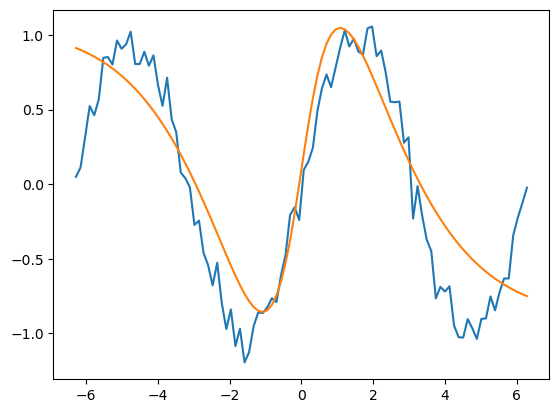

In [9]:
import matplotlib.pyplot as plt

plt.plot(X,y)
plt.plot(X,y_pred.data)

### Module and Linear and back prop CrossEntropy

In [8]:
import numpy as np
from my_ml.mytorch.nn.module import Module
from my_ml.mytorch.nn.linear import Linear
from my_ml.mytorch.nn.activations import ReLU,Sigmoid
from my_ml.mytorch.nn.loss import MSE,CrossEntropy
from my_ml.mytorch.optim import SGD
from my_ml.mytorch import tensor

In [12]:
from sklearn.datasets import load_digits
digits = load_digits()
X = digits.data.astype('float32')
y = digits.target

In [13]:
X.shape

(1797, 64)

In [14]:
def predict(logits):
    return logits.data.argmax(axis=1)

def accuracy(y_pred, y_true):
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)
    return (y_pred == y_true).mean()

In [15]:
from my_ml.mytorch.nn.module import Module
from my_ml.mytorch.nn.linear import Linear
from my_ml.mytorch.nn.activations import ReLU, Sigmoid

class StrongMLP(Module):
    def __init__(self, input_dim=64, hidden1=128, hidden2=64, hidden3=32, num_classes=10):
        super().__init__()

        self.fc1 = Linear(input_dim, hidden1)
        self.act1 = ReLU()

        self.fc2 = Linear(hidden1, hidden2)
        self.act2 = ReLU()

        self.fc3 = Linear(hidden2, hidden3)
        self.act3 = ReLU()

        self.fc4 = Linear(hidden3, num_classes)  # raw logits

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        x = self.act3(self.fc3(x))
        x = self.fc4(x)
        return x
    
model = StrongMLP(input_dim=64, hidden1=128, hidden2=64, hidden3=32, num_classes=10)

loss_fn = CrossEntropy()
optimizer = Adam(model.parameters(), lr=0.01)
for epoch in range(2000):
    logits = model(X)
    loss = loss_fn(logits, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    y_pred = predict(logits)
    acc = accuracy(y_pred,y)
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss.data} | accuracy : {acc}")


Epoch 0 | Loss: 3.2539953995126836 | accuracy : 0.09849749582637729
Epoch 20 | Loss: 1.6612537988603746 | accuracy : 0.6889259877573733
Epoch 40 | Loss: 0.5346951694159485 | accuracy : 0.8347245409015025
Epoch 60 | Loss: 0.4627229133689922 | accuracy : 0.8803561491374513
Epoch 80 | Loss: 0.5247215674386386 | accuracy : 0.8964941569282137
Epoch 100 | Loss: 0.7800389675215609 | accuracy : 0.857540345019477
Epoch 120 | Loss: 0.39320851903318416 | accuracy : 0.9204229271007234
Epoch 140 | Loss: 0.432939590263354 | accuracy : 0.9259877573734001
Epoch 160 | Loss: 0.28627171223804365 | accuracy : 0.9638286032276016
Epoch 180 | Loss: 0.8886853018062965 | accuracy : 0.9070673344462994
Epoch 200 | Loss: 0.772375391924691 | accuracy : 0.9365609348914858
Epoch 220 | Loss: 0.6578768908503122 | accuracy : 0.9449081803005008
Epoch 240 | Loss: 1.2843710347937147 | accuracy : 0.9476905954368392
Epoch 260 | Loss: 0.76962419889664 | accuracy : 0.9610461880912632
Epoch 280 | Loss: 0.7991388175772373 | acc

In [16]:
y_pred = model(X).data.argmax(axis = 1)
print(accuracy(y,y_pred))
print(confusion_matrix(y,y_pred))

1.0
[[178   0   0   0   0   0   0   0   0   0]
 [  0 182   0   0   0   0   0   0   0   0]
 [  0   0 177   0   0   0   0   0   0   0]
 [  0   0   0 183   0   0   0   0   0   0]
 [  0   0   0   0 181   0   0   0   0   0]
 [  0   0   0   0   0 182   0   0   0   0]
 [  0   0   0   0   0   0 181   0   0   0]
 [  0   0   0   0   0   0   0 179   0   0]
 [  0   0   0   0   0   0   0   0 174   0]
 [  0   0   0   0   0   0   0   0   0 180]]


In [17]:

def show_digit_and_predict(model, image_64):
    """
    image_64: NumPy array or list of length 64
    model: your trained PyTorch MLP
    """
    img = np.array(image_64).reshape(8, 8)  # reshape to 8x8

    # --- Display image ---
    plt.imshow(img, cmap='gray')
    plt.title("Digit Image")
    plt.axis('off')
    plt.show()

    # --- Predict ---
    x = torch.tensor(image_64, dtype=torch.float32)
    logits = model(x)
    pred = logits.data.argmax(axis = 1)

    print("Predicted digit:", pred)


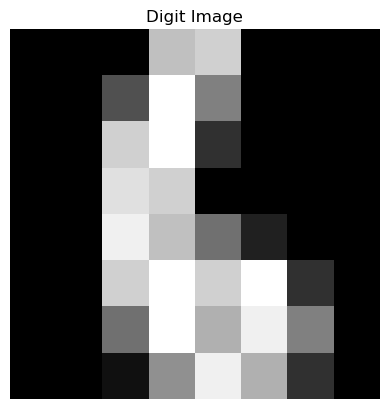

Predicted digit: [6]
Actual digit: 6


In [18]:
from sklearn.datasets import load_digits
digits = load_digits()

sample_index = 6
image = digits.data[sample_index]

show_digit_and_predict(model, image)
print("Actual digit:", y[sample_index])